In [31]:
import torch,torchvision
import numpy as np
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import os
import random
import torch.optim as optim
import matplotlib.pyplot as plt
import pandas as pd
RANDOM=42

root= ".data/"
atrtifacts_folder= "artifacts/"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE = 256 if device.type == "cuda" else 64
print(device)
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


cpu


In [32]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)), 
])
set_seed(RANDOM)
data_train = torchvision.datasets.EMNIST(root=root,train=True, split="balanced",download=True, transform= transform)
data_test= torchvision.datasets.EMNIST(root=root,train=0 , split="balanced",download=True,transform= transform)


BATCH_SIZE = 256 if device.type == "cuda" else 64


NUM_WORKERS = 0 if os.name == "nt" else 2

# train/val split
val_ratio = 0.1
val_size = int(len(data_train) * val_ratio)
train_size = len(data_train) - val_size

gen = torch.Generator().manual_seed(42)
train_ds, val_ds = random_split(data_train, [train_size, val_size], generator=gen)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
test_loader = DataLoader(
    data_test, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)


x_batch, y_batch = next(iter(train_loader))
print("x_batch:", x_batch.shape, x_batch.dtype)
print("y_batch:", y_batch.shape, y_batch.dtype)

x_batch: torch.Size([64, 1, 28, 28]) torch.float32
y_batch: torch.Size([64]) torch.int64


In [33]:
class MLP(nn.Module):
    def __init__(
        self,
        input_dim: int = 28 * 28,
        hidden_dims: tuple = (256,256, 128),
        num_classes: int = 64,
        activation: str = "relu",
        dropout_p: float = 0.0,
        use_batchnorm: bool = False,
    ):
        super().__init__()

        act = activation.lower()
        if act == "relu":
            act_layer = nn.ReLU
        elif act == "tanh":
            act_layer = nn.Tanh
        elif act == "gelu":
            act_layer = nn.GELU
        else:
            raise ValueError(f"Unknown activation: {activation}")

        layers = [nn.Flatten()]

        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(act_layer())
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            prev = h

        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


In [34]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    # Accuracy для классификации: logits -> argmax -> сравнение с y_true.
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()


def plot_history(history: dict, title: str = "",save_as=None) -> None:
    # history ожидается вида:
    # {
    #   "train_loss": [...], "val_loss": [...],
    #   "train_acc": [...],  "val_acc": [...]
    # }
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title((title + " (loss)") if title else "loss")
    plt.legend()
    plt.grid(True)
    if save_as:
        plt.savefig(atrtifacts_folder+"figures/"+save_as)
    plt.show()

    plt.figure()
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title((title + " (accuracy)") if title else "accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()
    

def plot_history_compared(history: dict,history2: dict,exp1_name:str="",exp2_name:str="", title: str = "",save_as=None) -> None:
    # history ожидается вида:
    # {
    #   "train_loss": [...], "val_loss": [...],
    #   "train_acc": [...],  "val_acc": [...]
    # }
    epochs = np.arange(1, len(history["train_loss"]) + 1)
    fig, axs = plt.subplots(2)
    
    
    axs[0].plot(epochs, history["val_loss"], label="val_loss "+exp1_name)
    axs[0].plot(epochs, history2["val_loss"], label="val_loss "+exp2_name)
    
    axs[0].set(ylabel=("loss"),xlabel=("epoch"))
    axs[0].set_title((title + " (loss)") if title else "loss")
    axs[0].legend()
    axs[0].grid(True)
    

    
    axs[1].plot(epochs, history["val_acc"], label="val_acc "+exp1_name)
    axs[1].plot(epochs, history2["val_acc"], label="val_acc "+exp2_name)
    axs[1].set(ylabel=("accuracy"),xlabel=("epoch"))
    axs[1].set_title((title + " (accuracy)") if title else "loss")
    axs[1].legend()
    axs[1].grid(True)
    if save_as:
        fig.savefig(atrtifacts_folder+"figures/"+ save_as)
    fig.show()
    

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()  # включаем train-режим (Dropout/BatchNorm!)
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()  # включаем eval-режим (Dropout/BatchNorm!)
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs: int = 20,
    early_stopping=None,
    verbose: bool = True,
):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if verbose:
            print(
                f"epoch {epoch:02d}/{epochs} | "
                f"train loss={tr_loss:.4f}, acc={tr_acc:.4f} | "
                f"val loss={va_loss:.4f}, acc={va_acc:.4f}"
            )

        if early_stopping is not None:
            should_stop = early_stopping.step(va_acc, model)
            if should_stop:
                if verbose:
                    print(
                        f"EarlyStopping: остановка на эпохе {epoch}. "
                        f"Лучший val_acc={early_stopping.best_score:.4f}"
                    )
                early_stopping.restore_best(model)
                break

    return history
def clear():
    f = open(atrtifacts_folder+"runs.csv","w")
    f.write('')
    f.close()
    

def log_csv( id:str ,
            dataset:str,
            seed:int,
            model_summary:str,
            optimizer:str,
            lr,
            momentum,
            history,
             weight_deacay =0):

    df= pd.DataFrame({"experiment_id":[id], "dataset":[dataset],"seed":[seed],"model_summary":[model_summary],"optimizer":[optimizer],"lr":[lr],"momentum":[momentum],"weight_decay":[weight_deacay,],"epochs_trained":[len(history["train_loss"])],"best_val_accuracy":[history['val_acc'][-1]],"best_val_loss":[history['val_loss'][-1]] },columns=["experiment_id", "dataset","seed","model_summary","optimizer","lr","momentum","weight_decay","epochs_trained","best_val_accuracy","best_val_loss"],index=None)
    try:
        df.to_csv(atrtifacts_folder+"runs.csv",header=(True if os.path.getsize(atrtifacts_folder+"runs.csv")==0 else None),index=None, mode="a")
    except:
        df.to_csv(atrtifacts_folder+"runs.csv",header=True,index=None, mode="a")


In [35]:
clear()

## E1

epoch 01/20 | train loss=1.1450, acc=0.6589 | val loss=0.7378, acc=0.7677
epoch 02/20 | train loss=0.6425, acc=0.7894 | val loss=0.6155, acc=0.8050
epoch 03/20 | train loss=0.5427, acc=0.8163 | val loss=0.5923, acc=0.8053
epoch 04/20 | train loss=0.4916, acc=0.8299 | val loss=0.5338, acc=0.8270
epoch 05/20 | train loss=0.4537, acc=0.8413 | val loss=0.5222, acc=0.8245
epoch 06/20 | train loss=0.4285, acc=0.8473 | val loss=0.5342, acc=0.8263
epoch 07/20 | train loss=0.4047, acc=0.8539 | val loss=0.5200, acc=0.8322
epoch 08/20 | train loss=0.3864, acc=0.8598 | val loss=0.5084, acc=0.8331
epoch 09/20 | train loss=0.3697, acc=0.8637 | val loss=0.4985, acc=0.8347
epoch 10/20 | train loss=0.3557, acc=0.8673 | val loss=0.5140, acc=0.8396
epoch 11/20 | train loss=0.3419, acc=0.8719 | val loss=0.5296, acc=0.8368
epoch 12/20 | train loss=0.3316, acc=0.8749 | val loss=0.5320, acc=0.8335
epoch 13/20 | train loss=0.3223, acc=0.8770 | val loss=0.5308, acc=0.8369
epoch 14/20 | train loss=0.3086, acc=0

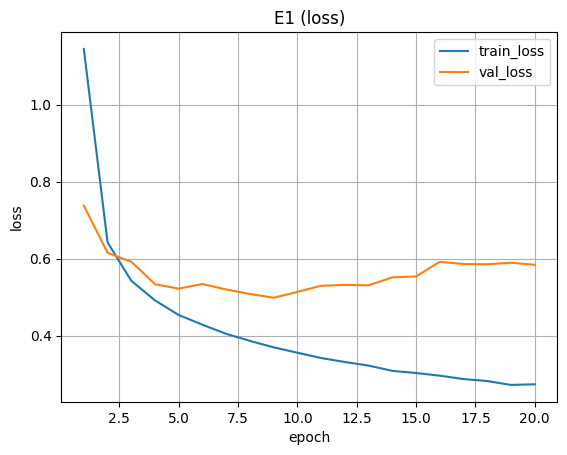

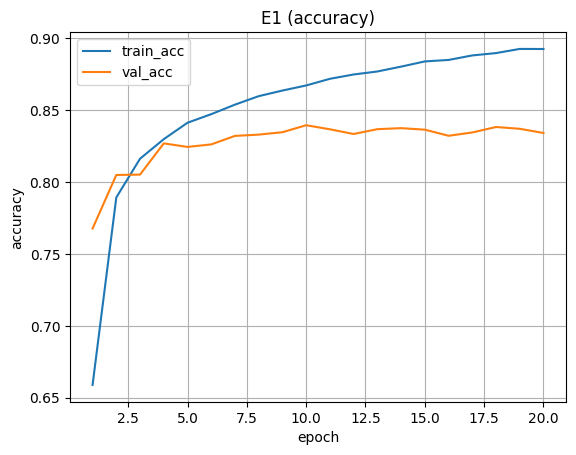

In [36]:
set_seed(RANDOM)
model = MLP( dropout_p=0.0, use_batchnorm=False).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

history= fit(
    model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)
plot_history(history, title="E1")
log_csv("E1","EMNIST",RANDOM,"hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=False","Adam",1e-3,0,history)


## E2

epoch 01/20 | train loss=1.4397, acc=0.5747 | val loss=0.7990, acc=0.7535
epoch 02/20 | train loss=0.9144, acc=0.7127 | val loss=0.6683, acc=0.7862
epoch 03/20 | train loss=0.8155, acc=0.7373 | val loss=0.6107, acc=0.7989
epoch 04/20 | train loss=0.7633, acc=0.7542 | val loss=0.5790, acc=0.8109
epoch 05/20 | train loss=0.7299, acc=0.7629 | val loss=0.5535, acc=0.8151
epoch 06/20 | train loss=0.7044, acc=0.7680 | val loss=0.5379, acc=0.8241
epoch 07/20 | train loss=0.6950, acc=0.7731 | val loss=0.5310, acc=0.8252
epoch 08/20 | train loss=0.6774, acc=0.7772 | val loss=0.5125, acc=0.8309
epoch 09/20 | train loss=0.6631, acc=0.7800 | val loss=0.5166, acc=0.8271
epoch 10/20 | train loss=0.6536, acc=0.7837 | val loss=0.5424, acc=0.8187
epoch 11/20 | train loss=0.6445, acc=0.7851 | val loss=0.5230, acc=0.8227
epoch 12/20 | train loss=0.6386, acc=0.7876 | val loss=0.5059, acc=0.8289
epoch 13/20 | train loss=0.6289, acc=0.7908 | val loss=0.5071, acc=0.8309
epoch 14/20 | train loss=0.6253, acc=0

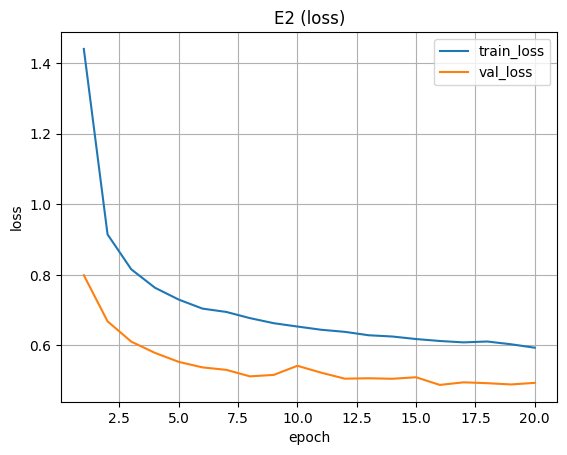

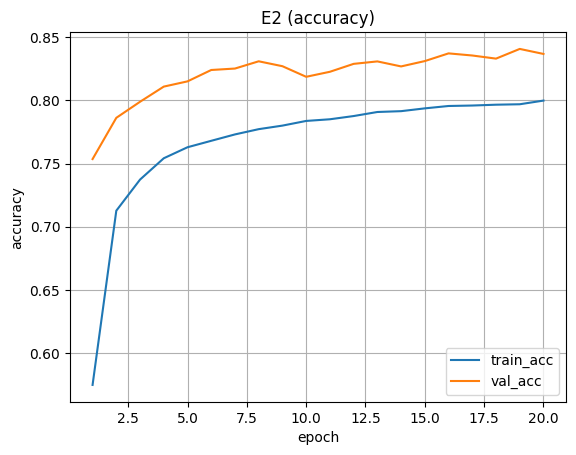

In [37]:
set_seed(RANDOM)
model = MLP( dropout_p=0.2, use_batchnorm=False).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

history= fit(
    model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)
plot_history(history, title="E2")
log_csv("E2","EMNIST",RANDOM,"hidden_dims=(256, 128), dropout_p=0.2, use_batchnorm=False","Adam",1e-3,0,history)

## E3

epoch 01/20 | train loss=0.8624, acc=0.7465 | val loss=0.5486, acc=0.8205
epoch 02/20 | train loss=0.5167, acc=0.8246 | val loss=0.4908, acc=0.8378
epoch 03/20 | train loss=0.4490, acc=0.8428 | val loss=0.4667, acc=0.8445
epoch 04/20 | train loss=0.4051, acc=0.8559 | val loss=0.4423, acc=0.8510
epoch 05/20 | train loss=0.3764, acc=0.8628 | val loss=0.4351, acc=0.8521
epoch 06/20 | train loss=0.3520, acc=0.8701 | val loss=0.4304, acc=0.8531
epoch 07/20 | train loss=0.3305, acc=0.8754 | val loss=0.4185, acc=0.8611
epoch 08/20 | train loss=0.3126, acc=0.8816 | val loss=0.4362, acc=0.8541
epoch 09/20 | train loss=0.2963, acc=0.8861 | val loss=0.4252, acc=0.8581
epoch 10/20 | train loss=0.2826, acc=0.8909 | val loss=0.4168, acc=0.8616
epoch 11/20 | train loss=0.2716, acc=0.8933 | val loss=0.4293, acc=0.8602
epoch 12/20 | train loss=0.2605, acc=0.8969 | val loss=0.4408, acc=0.8592
epoch 13/20 | train loss=0.2528, acc=0.8989 | val loss=0.4404, acc=0.8576
epoch 14/20 | train loss=0.2427, acc=0

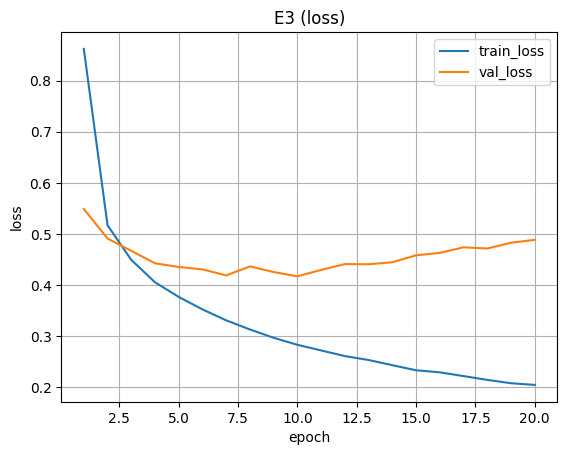

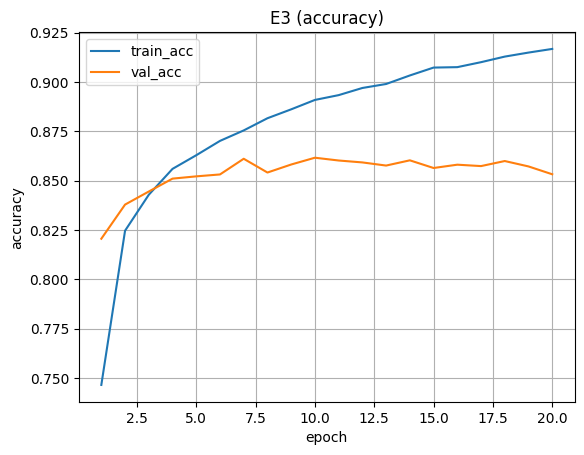

In [38]:
set_seed(RANDOM)
model = MLP( dropout_p=0.0, use_batchnorm=True).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

history= fit(
    model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)
plot_history(history, title="E3",save_as="curves_best.png")
log_csv("E3","EMNIST",RANDOM,"hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True","Adam",1e-3,0,history)

In [39]:
set_seed(RANDOM)
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Baseline test: loss={test_loss:.4f}, acc={test_acc:.4f}")

Baseline test: loss=0.5115, acc=0.8546


## E4

In [40]:
class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score: float, model: nn.Module) -> bool:
        # score: чем больше, тем лучше (например, val_acc).
        # Возвращает True, если нужно остановиться.
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False

        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

epoch 01/20 | train loss=0.8918, acc=0.7419 | val loss=0.5783, acc=0.8170
epoch 02/20 | train loss=0.5268, acc=0.8236 | val loss=0.5020, acc=0.8332
epoch 03/20 | train loss=0.4574, acc=0.8428 | val loss=0.4805, acc=0.8400
epoch 04/20 | train loss=0.4181, acc=0.8528 | val loss=0.4555, acc=0.8474
epoch 05/20 | train loss=0.3883, acc=0.8608 | val loss=0.4526, acc=0.8512
epoch 06/20 | train loss=0.3617, acc=0.8690 | val loss=0.4413, acc=0.8550
epoch 07/20 | train loss=0.3451, acc=0.8725 | val loss=0.4533, acc=0.8497
epoch 08/20 | train loss=0.3272, acc=0.8784 | val loss=0.4473, acc=0.8513
epoch 09/20 | train loss=0.3127, acc=0.8824 | val loss=0.4288, acc=0.8612
epoch 10/20 | train loss=0.2994, acc=0.8854 | val loss=0.4512, acc=0.8548
epoch 11/20 | train loss=0.2873, acc=0.8904 | val loss=0.4480, acc=0.8583
epoch 12/20 | train loss=0.2788, acc=0.8933 | val loss=0.4538, acc=0.8556
epoch 13/20 | train loss=0.2693, acc=0.8952 | val loss=0.4515, acc=0.8573
EarlyStopping: остановка на эпохе 13. 

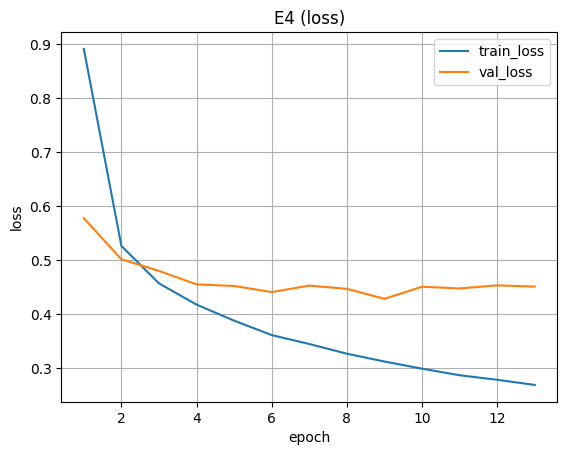

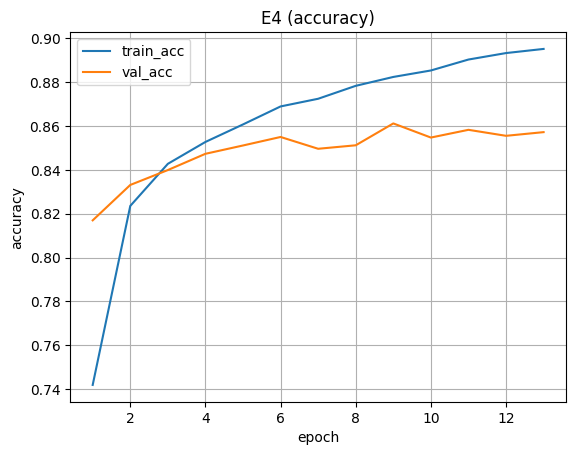

In [41]:
set_seed(RANDOM)
model = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
es = EarlyStopping(patience=4, min_delta=0.0005)
history_baseline = fit(
    model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=es
)

plot_history(history_baseline, title="E4")
log_csv("E4","EMNIST",RANDOM,"hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True","Adam",1e-3,0,history)
torch.save(model.state_dict(),atrtifacts_folder+"best_model.pt")

## O1

epoch 01/7 | train loss=1.1657, acc=0.6470 | val loss=0.8591, acc=0.7383
epoch 02/7 | train loss=0.8735, acc=0.7263 | val loss=0.7526, acc=0.7695
epoch 03/7 | train loss=0.7884, acc=0.7504 | val loss=0.8278, acc=0.7348
epoch 04/7 | train loss=0.7504, acc=0.7617 | val loss=0.7108, acc=0.7777
epoch 05/7 | train loss=0.7167, acc=0.7708 | val loss=0.7341, acc=0.7675
epoch 06/7 | train loss=0.6877, acc=0.7776 | val loss=0.6918, acc=0.7844
epoch 07/7 | train loss=0.6759, acc=0.7824 | val loss=0.7058, acc=0.7775


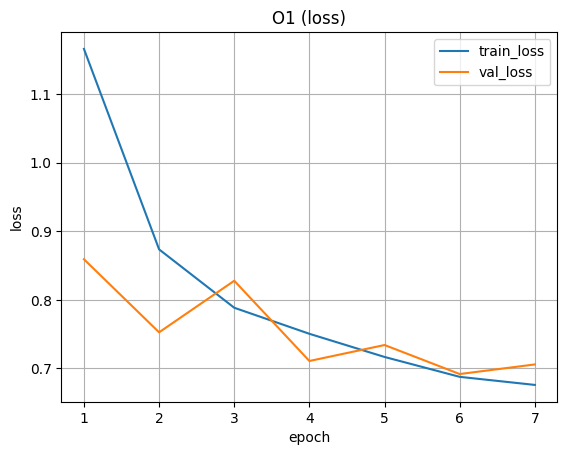

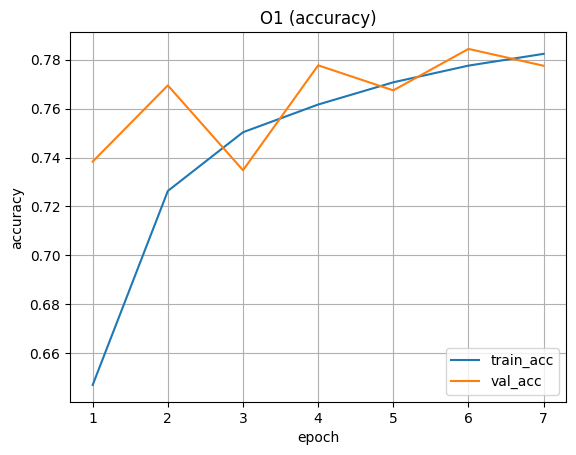

In [42]:
set_seed(RANDOM)
model = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-1)

history_baseline = fit(
    model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=7,
    early_stopping=None
)
o1_history= history_baseline.copy()
plot_history(history_baseline, title="O1")
log_csv("O1","EMNIST",RANDOM,"hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True","Adam",1e-3,0,history)

## O2

epoch 01/7 | train loss=4.2842, acc=0.0153 | val loss=4.2822, acc=0.0146
epoch 02/7 | train loss=4.2840, acc=0.0154 | val loss=4.2802, acc=0.0142
epoch 03/7 | train loss=4.2839, acc=0.0148 | val loss=4.2797, acc=0.0139
epoch 04/7 | train loss=4.2840, acc=0.0154 | val loss=4.2863, acc=0.0134
epoch 05/7 | train loss=4.2841, acc=0.0151 | val loss=4.2826, acc=0.0146
epoch 06/7 | train loss=4.2836, acc=0.0150 | val loss=4.2820, acc=0.0144
epoch 07/7 | train loss=4.2841, acc=0.0153 | val loss=4.2797, acc=0.0149


C:\Users\study\AppData\Local\Temp\ipykernel_29876\3394637969.py:66: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


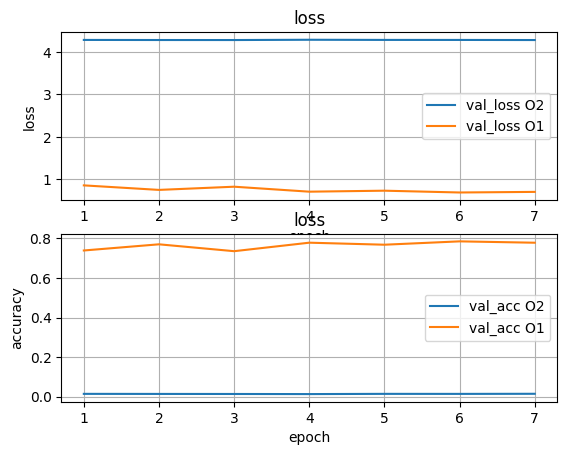

In [43]:
set_seed(RANDOM)
model = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-11)

history_baseline = fit(
    model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=7,
    early_stopping=None
)

plot_history_compared(history_baseline,o1_history,"O2","O1",save_as="curves_lr_extremes.png")
log_csv("O2","EMNIST",RANDOM,"hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True","Adam",1e-3,0,history)

## O3

epoch 01/7 | train loss=2.7825, acc=0.4721 | val loss=2.2182, acc=0.6096
epoch 02/7 | train loss=2.0509, acc=0.6470 | val loss=1.8691, acc=0.6942
epoch 03/7 | train loss=1.8267, acc=0.7069 | val loss=1.7260, acc=0.7404
epoch 04/7 | train loss=1.7182, acc=0.7378 | val loss=1.6212, acc=0.7568
epoch 05/7 | train loss=1.6696, acc=0.7510 | val loss=1.5913, acc=0.7603
epoch 06/7 | train loss=1.6481, acc=0.7563 | val loss=1.6165, acc=0.7647
epoch 07/7 | train loss=1.6347, acc=0.7591 | val loss=1.5646, acc=0.7617


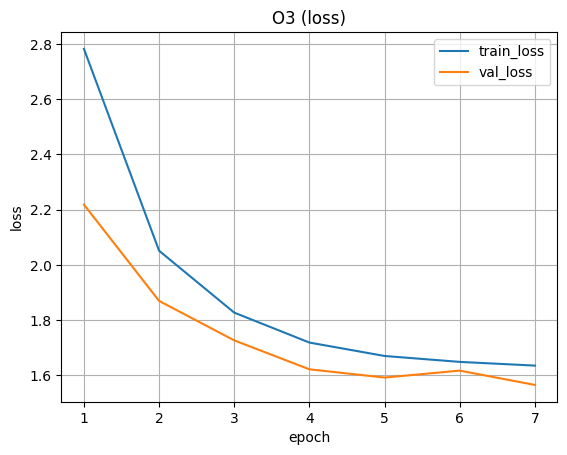

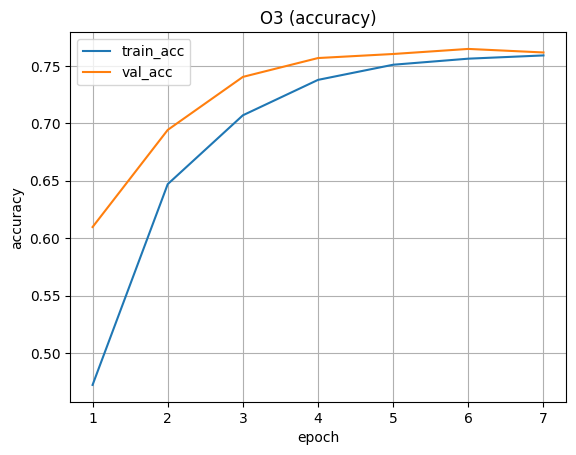

In [ ]:
set_seed(RANDOM)
model = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=1e-3,momentum=0.8,weight_decay=0.05)

history_baseline = fit(
    model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=7,
    early_stopping=None
)

plot_history(history_baseline, title="O3")
log_csv("O3","EMNIST",RANDOM,"hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True","SGD",1e-3,0.8,history,0.05)